In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!jupyter nbconvert --to script /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new6.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new6.ipynb to script
[NbConvertApp] Writing 7352 bytes to /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new6.txt


In [3]:
!mv /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new6.txt \
    /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new6.py

In [4]:
import sys
sys.path.append("/content/drive/MyDrive/DL-for-time-series-forecasting/src")   # 添加到 PYTHONPATH
# ---------- import your three model helpers ----------
from models.lstm_model import SeqLSTM, run_lstm_forecast
from models.lgbm_model import run_lgbm_forecast, generate_lag_features
from models.darnn_model_new6 import DARNN, run_darnn_forecast                       # uploaded as darnn_model.py


In [16]:
# robustness_test.py
import math, os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb

In [17]:
# — 数据集路径
base_path = "/content/drive/MyDrive/DL-for-time-series-forecasting"
datasets = {
    "air_quality":   f"{base_path}/data/data_clean/air_quality.csv",
    "energy":        f"{base_path}/data/data_clean/energy.csv",
    "gait":          f"{base_path}/data/data_clean/gait.csv",
    "metro":         f"{base_path}/data/data_clean/metro.csv",
    "productivity":  f"{base_path}/data/data_clean/productivity.csv"
    }

In [18]:
# ---------------- ① 读入单变量时间序列 ---------------- #
#series = pd.read_csv(datasets["energy"], header=None).iloc[:, 0].values  # 〈--- 换成你的数据
# ——— 读取纯数值序列 ———
path = datasets["gait"]   # 或者你要的 key

# 1. 读取 CSV，只取第二列（索引为 1）
#    如果 CSV 文件带有表头，这里 header=0；如果没有，就用 header=None
df = pd.read_csv(
    path,
    header=0,       # 如果没有列名则改成 header=None
    usecols=[1]     # 只读取第二列
)

# 2. 取出这一列，强制转为 float，再取 NumPy 值
series = df.iloc[:, 0].astype(float).values

# 验证
#print(type(series), series.dtype, series.shape)

In [19]:
# train_and_robustness.py
import os, time, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


# =============== 0. 环境与固定超参 ===============
WINDOW      = 12
TEST_SIZE   = 0.2
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

lstm_hp = dict(HIDDEN_SIZE=128, N_LAYERS=2, HORIZON=1, DROPOUT=0.2,
               LEARNING_RATE=1e-3, EPOCHS=60, PATIENCE=8,
               BATCH_SIZE=128, DEVICE=DEVICE)

darnn_hp = dict(HIDDEN_SIZE=64,  LEARNING_RATE=1e-3,
                EPOCHS=60, PATIENCE=8, BATCH_SIZE=128, DEVICE=DEVICE,
                PRINT_EVERY=1)




# =============== 2. LSTM 训练 ===============
def build_loaders(ts: np.ndarray):
    df = generate_lag_features(ts, WINDOW)
    X, y = df.drop(columns="y").values, df["y"].values
    X_tr, X_tv, y_tr, y_tv = train_test_split(X, y, test_size=TEST_SIZE, shuffle=False)
    X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.15, shuffle=False)

    def to_loader(x, y, bs):
        tx = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
        ty = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
        return DataLoader(TensorDataset(tx, ty), batch_size=bs, shuffle=True)
    train_loader = to_loader(X_tr, y_tr, lstm_hp["BATCH_SIZE"])
    val_loader   = to_loader(X_va, y_va, lstm_hp["BATCH_SIZE"])
    test_loader  = to_loader(X_tv, y_tv, lstm_hp["BATCH_SIZE"])
    return train_loader, val_loader, test_loader, y_tv               # 返回 y_test 备用

print("▶ Training LSTM …")
tr_loader, va_loader, te_loader, y_test_lstm = build_loaders(series)
_ = run_lstm_forecast((tr_loader,va_loader,te_loader), 1, lstm_hp, return_train_loss=False)
print("✅ best_model.pth saved\n")

# =============== 3. DARNN 训练 ===============
print("▶ Training DARNN …")
df_lag = generate_lag_features(series, WINDOW)
X_all  = df_lag.drop(columns="y").values.reshape(-1, WINDOW, 1).astype("float32")
y_all  = df_lag["y"].values.reshape(-1,1).astype("float32")
X_tr, X_tv, y_tr, y_tv = train_test_split(X_all, y_all, test_size=TEST_SIZE, shuffle=False)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.15, shuffle=False)
_ = run_darnn_forecast(X_tr,y_tr,X_va,y_va,X_tv,y_tv, darnn_hp)      # 内部保存 best_darnn.pth
print("✅ best_darnn.pth saved\n")


▶ Training LSTM …


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([128, 1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([95, 1])) that is different to the input size (torch.Size([95, 1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([55, 1])) that is different to the input size (torch.Size([55, 1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  retu

Epoch 01 | trainMSE=254.3207 | valMSE=278.4734
Epoch 02 | trainMSE=251.9456 | valMSE=278.9119
Epoch 03 | trainMSE=251.9615 | valMSE=279.0141
Epoch 04 | trainMSE=251.9494 | valMSE=279.5451
Epoch 05 | trainMSE=251.9328 | valMSE=279.7802
Epoch 06 | trainMSE=251.9307 | valMSE=280.0435
Epoch 07 | trainMSE=251.9714 | valMSE=280.9443
Epoch 08 | trainMSE=251.9564 | valMSE=279.2235
Epoch 09 | trainMSE=251.9345 | valMSE=279.3760
Early stopping triggered.
✅ best_model.pth saved

▶ Training DARNN …
DEBUG shapes:
  Ytr: torch.Size([123615, 1])
  Yva: torch.Size([21815, 1])
  Yte: torch.Size([36358, 1])
Epoch 01 | trainMSE=397.1735 | valMSE=455.1048
Epoch 02 | trainMSE=395.3685 | valMSE=453.1189
Epoch 03 | trainMSE=393.5836 | valMSE=451.1425
Epoch 04 | trainMSE=391.8109 | valMSE=449.1700
Epoch 05 | trainMSE=390.0445 | valMSE=447.1904
Epoch 06 | trainMSE=388.2744 | valMSE=445.1948
Epoch 07 | trainMSE=386.4899 | valMSE=443.1830
Epoch 08 | trainMSE=384.6924 | valMSE=441.1550
Epoch 09 | trainMSE=382.879

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006453 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 145430, number of used features: 12
[LightGBM] [Info] Start training from score 12.061222


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 145430, number of used features: 12
[LightGBM] [Info] Start training from score 12.061264


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



=== LGBM Robustness ===
Perturbation |        MAE |       RMSE |    ΔMAE% |   ΔRMSE%
------------------------------------------------------------
clean        |     0.6288 |     1.6948 |    0.00% |    0.00%
noise_0.05   |     0.6402 |     1.6971 |   +1.81% |   +0.14%

=== LSTM Robustness ===
Perturbation |        MAE |       RMSE |    ΔMAE% |   ΔRMSE%
------------------------------------------------------------
clean        |    11.7826 |    16.1379 |    0.00% |    0.00%
noise_0.05   |    11.7827 |    16.1378 |   +0.00% |   -0.00%

=== DARNN Robustness ===
Perturbation |        MAE |       RMSE |    ΔMAE% |   ΔRMSE%
------------------------------------------------------------
clean        |    13.1983 |    18.8266 |    0.00% |    0.00%
noise_0.05   |    13.2079 |    18.8296 |   +0.07% |   +0.02%


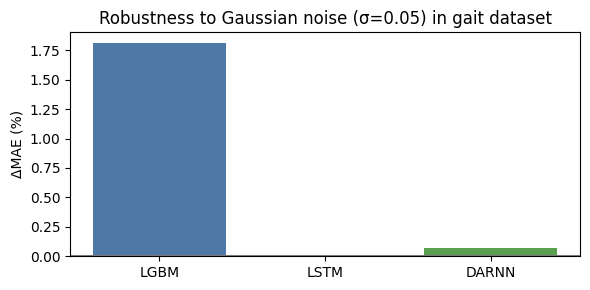

In [20]:
# =============== 4. Robustness test (MAE / RMSE / Δ%) ===============
from sklearn.metrics import mean_absolute_error, mean_squared_error

def add_gauss(a, σ=0.05):
    return a + np.random.normal(0, σ, size=a.shape)

series_noise = add_gauss(series, 0.05)

# ---------- helper: pretty print ----------
def print_block(name, mc, rc, mn, rn):
    d_mae  = (mn-mc)/mc*100
    d_rmse = (rn-rc)/rc*100
    print(f"\n=== {name} Robustness ===")
    print(f"{'Perturbation':<12} | {'MAE':>10} | {'RMSE':>10} | {'ΔMAE%':>8} | {'ΔRMSE%':>8}")
    print("-"*60)
    print(f"{'clean':<12} | {mc:10.4f} | {rc:10.4f} | {0:7.2f}% | {0:7.2f}%")
    print(f"{'noise_0.05':<12} | {mn:10.4f} | {rn:10.4f} | {d_mae:+7.2f}% | {d_rmse:+7.2f}%")
    return d_mae                                     # 方便后面柱状图

# ---------- 4-A  LGBM ----------
def lgbm_metrics(ts):
    y_true, y_pred, _ = run_lgbm_forecast(ts, WINDOW, TEST_SIZE)
    return (mean_absolute_error(y_true, y_pred),
            math.sqrt(mean_squared_error(y_true, y_pred)))

mae_lgb_c, rmse_lgb_c = lgbm_metrics(series)
mae_lgb_n, rmse_lgb_n = lgbm_metrics(series_noise)

# ---------- 4-B  LSTM ----------
def lstm_metrics(ts):
    _, _, te_loader, y_true = build_loaders(ts)
    lstm = SeqLSTM(1, lstm_hp["HIDDEN_SIZE"], lstm_hp["N_LAYERS"],
                   lstm_hp["HORIZON"], lstm_hp["DROPOUT"]).to(DEVICE)
    lstm.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
    lstm.eval()
    preds=[]
    with torch.no_grad():
        for xb,_ in te_loader:
            preds.append(lstm(xb.to(DEVICE)).cpu().numpy())
    preds = np.concatenate(preds).squeeze(-1)
    return (mean_absolute_error(y_true, preds),
            math.sqrt(mean_squared_error(y_true, preds)))

mae_lstm_c, rmse_lstm_c = lstm_metrics(series)
mae_lstm_n, rmse_lstm_n = lstm_metrics(series_noise)

# ---------- 4-C  DARNN ----------
def darnn_metrics(ts):
    loader, y_true = build_loaders(ts)[:2]  # 只要 test_loader
    # build_loaders 返回 4 个值，这里直接重新做 loader —— 与 LSTM 相同逻辑
    loader, y_true = build_loaders(ts)[2:]  # test_loader, y_tv
    darnn = DARNN(1, darnn_hp["HIDDEN_SIZE"], 1).to(DEVICE)
    darnn.load_state_dict(torch.load("best_darnn.pth", map_location=DEVICE))
    darnn.eval()
    preds=[]
    with torch.no_grad():
        for xb,_ in loader:
            y0 = torch.zeros((xb.size(0), 1), device=DEVICE)  # horizon=1
            out = darnn(xb.to(DEVICE), y0).cpu().numpy().squeeze(-1)
            preds.append(out)
    preds = np.concatenate(preds)
    return (mean_absolute_error(y_true, preds),
            math.sqrt(mean_squared_error(y_true, preds)))

mae_dn_c, rmse_dn_c = darnn_metrics(series)
mae_dn_n, rmse_dn_n = darnn_metrics(series_noise)

# ---------- 5. 打印三张表 ----------
d_lgb  = print_block("LGBM",  mae_lgb_c,  rmse_lgb_c,  mae_lgb_n,  rmse_lgb_n)
d_lstm = print_block("LSTM",  mae_lstm_c, rmse_lstm_c, mae_lstm_n, rmse_lstm_n)
d_dn   = print_block("DARNN", mae_dn_c,   rmse_dn_c,   mae_dn_n,   rmse_dn_n)

# ---------- 6. ΔMAE% 柱状图 ----------
labels = ["LGBM", "LSTM", "DARNN"]
deltas = [d_lgb, d_lstm, d_dn]

plt.figure(figsize=(6,3))
plt.bar(labels, deltas, color=["#4E79A7", "#F28E2B", "#59A14F"])
plt.axhline(0, color='gray')
plt.ylabel("ΔMAE (%)")
plt.title("Robustness to Gaussian noise (σ=0.05) in gait dataset")
plt.tight_layout()
plt.savefig("robustness_gait.png")
plt.show()


In [21]:
from google.colab import files

# 直接下载位于 /content 的文件
files.download('robustness_gait.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>